In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r'Housing1.csv')

In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

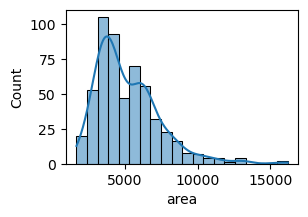

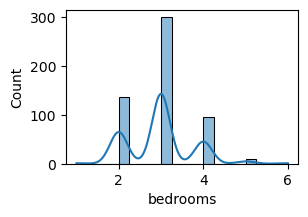

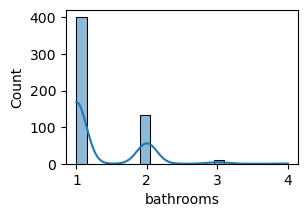

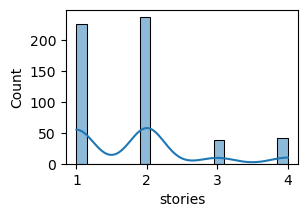

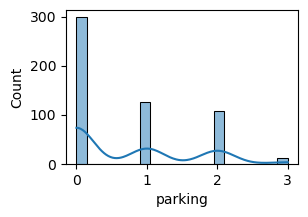

In [7]:
numeric_values=['area','bedrooms',	'bathrooms',	'stories','parking']
for col in numeric_values:
    plt.figure(figsize=(3,2))
    sns.histplot(df[col],kde=True,bins=20)

In [8]:
df[['mainroad',	'guestroom',	'basement',	'hotwaterheating',	'airconditioning', 'prefarea']].value_counts()

mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
yes       no         no        no               no               no          151
                                                yes              no           62
                     yes       no               no               no           43
no        no         no        no               no               no           42
yes       no         no        no               no               yes          32
                     yes       no               no               yes          21
          yes        yes       no               no               no           20
          no         yes       no               yes              no           19
                     no        no               yes              yes          18
          yes        yes       no               no               yes          18
                                                yes              yes          15
          no         yes       no  

In [9]:
df[['mainroad',	'guestroom',	'basement',	'hotwaterheating',	'airconditioning', 'prefarea']]=df[['mainroad',	'guestroom',
'basement',	'hotwaterheating',	'airconditioning', 'prefarea']].replace({'yes':1,'no':0})

In [10]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [11]:
df=pd.get_dummies(df,columns=['furnishingstatus'],drop_first=True)

In [12]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,False,True
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,True,False
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,False,True
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,False,False


In [13]:
df[['furnishingstatus_semi-furnished','furnishingstatus_unfurnished']]=df[['furnishingstatus_semi-furnished','furnishingstatus_unfurnished']].replace(
   { True:1,False:0}
)

In [14]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
std_cols=['area','bedrooms','bathrooms','stories','parking']
df[std_cols]=scaler.fit_transform(df[std_cols])

In [16]:
from scipy.stats import pearsonr
#pearson Correlation Calculation
#List of features to check against target
selected_features=[ 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']

correlations={
    feature: pearsonr(df[feature], df['price'])[0]
    for feature in selected_features

                      }
correlation_df=pd.DataFrame(list(correlations.items()),columns=['feature','Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation',ascending=False)

,feature,Pearson Correlation
0,area,0.535997
2,bathrooms,0.517545
8,airconditioning,0.452954
3,stories,0.420712
9,parking,0.384394
1,bedrooms,0.366494
10,prefarea,0.329777
4,mainroad,0.296898
5,guestroom,0.255517
6,basement,0.187057


In [17]:
cat_features=[ 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']


In [18]:
from scipy.stats import chi2_contingency
import pandas as pd
alpha=0.05

chi2_results={}
for col in cat_features:
    # contingency table (cross-tab)
    contingency_table = pd.crosstab(df[col], df['price'])
    
    # chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # check significance
    chi2_results[col] = {
        "chi2_stat": chi2,
        "p_value": p,
        "dof": dof,
        "significant": p < alpha
    }

# print results
for col, result in chi2_results.items():
    print(f"{col} vs price -> p-value: {result['p_value']:.4f}, Significant: {result['significant']}")

bedrooms vs price -> p-value: 0.9751, Significant: False
bathrooms vs price -> p-value: 0.0000, Significant: True
stories vs price -> p-value: 0.0001, Significant: True
mainroad vs price -> p-value: 0.1131, Significant: False
guestroom vs price -> p-value: 0.0001, Significant: True
basement vs price -> p-value: 0.0169, Significant: True
hotwaterheating vs price -> p-value: 0.2020, Significant: False
airconditioning vs price -> p-value: 0.0007, Significant: True
parking vs price -> p-value: 0.0164, Significant: True
prefarea vs price -> p-value: 0.0005, Significant: True
furnishingstatus_semi-furnished vs price -> p-value: 0.1890, Significant: False
furnishingstatus_unfurnished vs price -> p-value: 0.0036, Significant: True


In [19]:
final_df=df[['price','area','bathrooms','stories','guestroom','basement','airconditioning','parking','prefarea','furnishingstatus_unfurnished']]

In [20]:
from sklearn.model_selection import train_test_split
X=final_df.drop('price',axis=1)
y=final_df['price']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model=LinearRegression()

In [24]:
model.fit(X_train,y_train)

LinearRegression()

In [25]:
y_pred=model.predict(X_test)

In [26]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [27]:

r2 = r2_score(y_test, y_pred)

In [28]:
r2

0.6352713723142621

In [29]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

from sklearn.metrics import r2_score



In [30]:
r2 = r2_score(y_test, y_pred_ridge)

In [31]:
r2

0.6349046436831939

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
rf_model = RandomForestRegressor(
    n_estimators=100,   # kitne trees banane hain (default 100)
    random_state=42,    # repeatable result ke liye
)

In [34]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [35]:
y_pred_rf = rf_model.predict(X_test)

In [36]:
r2 = r2_score(y_test, y_pred_rf)

In [37]:
r2

0.6024099781205379

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
df.shape

(545, 14)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [41]:
model_1=LinearRegression()
scores = cross_val_score(model_1, X, y, cv=5, scoring='r2')

In [42]:
scores

array([ -2.03499644,  -5.23755491, -15.13727967, -20.39818861,
        -5.79173859])

In [43]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

In [44]:
scores

array([0.6108649 , 0.64070744, 0.56623523, 0.64385529, 0.62701014])

In [45]:
scores.mean()

np.float64(0.6177345994892199)